# Exploration des données RH et sportives

**Projet 12 — POC Avantages sportifs (Sport Data Solution)**

Objectifs de ce notebook :
1. Vérifier la **qualité** des deux fichiers sources (valeurs manquantes, doublons, incohérences).
2. Décrire la population : **pratique sportive**, âge, ancienneté, BU, **moyens de transport**, **localisation**.
3. **Détecter les déclarations suspectes** de mode de transport (distance domicile-bureau trop grande).
4. Donner un **premier ordre de grandeur du coût** des deux avantages.

> ⚠️ **Données personnelles** : ce notebook manipule des données RH (salaires, adresses).
> Aucun nom n'est affiché, les salariés sont désignés par leur identifiant.
> **Vider les sorties avant chaque commit** (`Kernel > Restart & Clear Output` ou `nbstripout`).

## 0. Préparation

In [1]:
import json
import math
import re
import unicodedata
import urllib.parse
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

from projet12.config import FICHIER_RH, FICHIER_SPORT, RACINE

# Couleurs : une seule teinte pour les graphiques à une série,
# orange pour la 2e catégorie, rouge réservé aux anomalies
BLEU, ORANGE, GRIS, ROUGE = "#2a78d6", "#eb6834", "#a3a29b", "#d03b3b"

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", 30)

AUJOURDHUI = pd.Timestamp.today().normalize()


def barres_horizontales(serie, titre, xlabel="Nombre de salariés", couleur=BLEU,
                        pct=True, total=None, trier=True):
    """Barres horizontales avec la valeur au bout de chaque barre.
    total : base du pourcentage (par défaut, la somme de la série)
    trier : trie par valeur ; sinon garde l'ordre de la série (ex. tranches d'âge)"""
    serie = serie.sort_values() if trier else serie.iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, max(2.5, 0.35 * len(serie) + 1)))
    ax.barh(serie.index.astype(str), serie.values, color=couleur, height=0.65)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    total = total or serie.sum()
    for y, v in enumerate(serie.values):
        etiquette = f"{v}  ({v / total:.0%})" if pct else f"{v}"
        ax.text(v, y, f" {etiquette}", va="center", fontsize=9, color="#3d3d3a")
    ax.set_title(titre)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, serie.max() * 1.25)
    plt.tight_layout()
    plt.show()

## 1. Chargement et qualité des données

In [2]:
rh_brut = pd.read_excel(FICHIER_RH)
sport_brut = pd.read_excel(FICHIER_SPORT)

print(f"Fichier RH    : {rh_brut.shape[0]} lignes x {rh_brut.shape[1]} colonnes")
print(f"Fichier sport : {sport_brut.shape[0]} lignes x {sport_brut.shape[1]} colonnes")
rh_brut.dtypes.to_frame("type")

Fichier RH    : 161 lignes x 11 colonnes
Fichier sport : 161 lignes x 2 colonnes


,type
ID salarié,int64
Nom,str
Prénom,str
Date de naissance,datetime64[us]
BU,str
Date d'embauche,datetime64[us]
Salaire brut,int64
Type de contrat,str
Nombre de jours de CP,int64
Adresse du domicile,str


In [3]:
# Valeurs manquantes et doublons
qualite = pd.DataFrame({
    "manquants RH": rh_brut.isna().sum(),
}).query("`manquants RH` > 0")
print("Valeurs manquantes (RH)    :", "aucune" if qualite.empty else qualite.to_dict())
print("Valeurs manquantes (sport) :", sport_brut.isna().sum().to_dict())
print("Identifiants en double     : RH =", rh_brut["ID salarié"].duplicated().sum(),
      "| sport =", sport_brut["ID salarié"].duplicated().sum())

ids_rh, ids_sport = set(rh_brut["ID salarié"]), set(sport_brut["ID salarié"])
print("Salariés RH absents du fichier sport :", len(ids_rh - ids_sport))
print("Salariés sport absents du fichier RH :", len(ids_sport - ids_rh))

Valeurs manquantes (RH)    : aucune
Valeurs manquantes (sport) : {'ID salarié': 0, "Pratique d'un sport": 66}
Identifiants en double     : RH = 0 | sport = 0
Salariés RH absents du fichier sport : 0
Salariés sport absents du fichier RH : 0


Les valeurs manquantes du fichier sport ne sont **pas des erreurs** : une cellule vide signifie
« ne pratique pas de sport ». On le traduit explicitement ci-dessous.

In [4]:
# Fusion et noms de colonnes simplifiés
df = rh_brut.merge(sport_brut, on="ID salarié", how="left").rename(columns={
    "ID salarié": "id_salarie", "Nom": "nom", "Prénom": "prenom",
    "Date de naissance": "date_naissance", "BU": "bu", "Date d'embauche": "date_embauche",
    "Salaire brut": "salaire_brut", "Type de contrat": "type_contrat",
    "Nombre de jours de CP": "jours_cp", "Adresse du domicile": "adresse",
    "Moyen de déplacement": "moyen_deplacement", "Pratique d'un sport": "sport_declare",
})

# Nettoyage : la faute de frappe "Runing" est corrigée
df["sport"] = df["sport_declare"].str.strip().replace({"Runing": "Course à pied"})
df["pratique_sport"] = df["sport"].notna()

# Variables dérivées
df["age"] = ((AUJOURDHUI - df["date_naissance"]).dt.days / 365.25).astype(int)
df["anciennete"] = (AUJOURDHUI - df["date_embauche"]).dt.days / 365.25
df["age_embauche"] = (df["date_embauche"] - df["date_naissance"]).dt.days / 365.25
df["tranche_age"] = pd.cut(df["age"], bins=[0, 29, 39, 49, 59, 99],
                           labels=["< 30 ans", "30-39 ans", "40-49 ans", "50-59 ans", "60 ans et +"])

def decouper_adresse(adresse):
    """Renvoie (code postal, commune). Tolère les adresses sans virgule ou sans code postal."""
    trouve = re.search(r"(\d{5})\s+([^,\d][^,]*)$", adresse)
    if trouve:
        return trouve.group(1), trouve.group(2).strip()
    return None, adresse.rsplit(",", 1)[-1].strip()   # pas de code postal : dernier segment


df[["code_postal", "commune"]] = [decouper_adresse(a) for a in df["adresse"]]
df["departement"] = df["code_postal"].str[:2]

MODES_SPORTIFS = {"Marche/running", "Vélo/Trottinette/Autres"}
df["trajet_sportif"] = df["moyen_deplacement"].isin(MODES_SPORTIFS)

# Adresses au format inhabituel (format attendu : "numéro rue, CP Commune")
sans_cp = df["code_postal"].isna()
sans_virgule = ~df["adresse"].str.contains(",")
print("Adresses sans code postal :", sans_cp.sum(), "-> salarié(s)", df.loc[sans_cp, "id_salarie"].tolist())
print("Adresses sans virgule     :", sans_virgule.sum(), "-> salarié(s)", df.loc[sans_virgule, "id_salarie"].tolist())
print("Valeurs de sport corrigées :", (df["sport_declare"] == "Runing").sum(), "x 'Runing' -> 'Course à pied'")

Adresses sans code postal : 1 -> salarié(s) [84233]
Adresses sans virgule     : 1 -> salarié(s) [71502]
Valeurs de sport corrigées : 18 x 'Runing' -> 'Course à pied'


In [5]:
# Contrôles de cohérence
controles = {
    "Embauche dans le futur": (df["date_embauche"] > AUJOURDHUI).sum(),
    "Embauché avant 16 ans": (df["age_embauche"] < 16).sum(),
    "Âge hors 16-70 ans": (~df["age"].between(16, 70)).sum(),
    "Salaire <= 0": (df["salaire_brut"] <= 0).sum(),
    "Jours de CP hors 0-40": (~df["jours_cp"].between(0, 40)).sum(),
}
pd.Series(controles, name="nb de lignes en anomalie").to_frame()

,nb de lignes en anomalie
Embauche dans le futur,0
Embauché avant 16 ans,0
Âge hors 16-70 ans,0
Salaire <= 0,0
Jours de CP hors 0-40,0


In [6]:
df[["age", "anciennete", "salaire_brut", "jours_cp"]].describe().round(1)

,age,anciennete,salaire_brut,jours_cp
count,161.0,161.0,161.0,161.0
mean,45.4,3.9,50426.3,27.0
std,11.9,1.5,14779.6,1.5
min,24.0,1.5,25570.0,25.0
25%,36.0,2.6,37910.0,26.0
50%,46.0,4.0,50580.0,27.0
75%,55.0,5.2,62760.0,28.0
max,66.0,6.5,74990.0,29.0


## 2. Pratique sportive

95 salariés déclarent un sport (59%), 66 n'en déclarent aucun (41%).


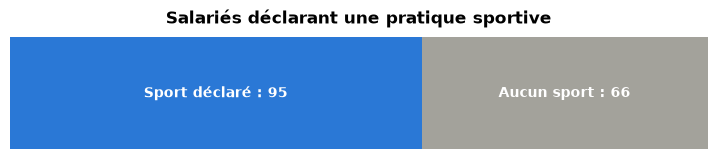

In [7]:
n_sport = df["pratique_sport"].sum()
n_total = len(df)
print(f"{n_sport} salariés déclarent un sport ({n_sport / n_total:.0%}), "
      f"{n_total - n_sport} n'en déclarent aucun ({1 - n_sport / n_total:.0%}).")

fig, ax = plt.subplots(figsize=(9, 1.6))
ax.barh([""], [n_sport], color=BLEU, height=0.5)
ax.barh([""], [n_total - n_sport], left=[n_sport], color=GRIS, height=0.5)
ax.text(n_sport / 2, 0, f"Sport déclaré : {n_sport}", ha="center", va="center", color="white", fontweight="bold")
ax.text(n_sport + (n_total - n_sport) / 2, 0, f"Aucun sport : {n_total - n_sport}", ha="center", va="center", color="white", fontweight="bold")
ax.set_xlim(0, n_total)
ax.axis("off")
ax.set_title("Salariés déclarant une pratique sportive")
plt.show()

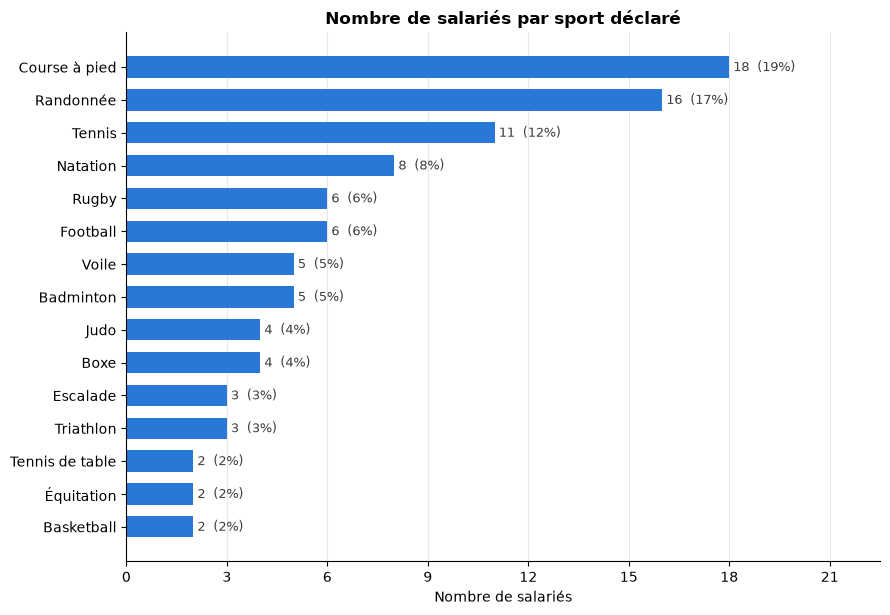

In [8]:
barres_horizontales(df["sport"].value_counts(), "Nombre de salariés par sport déclaré")

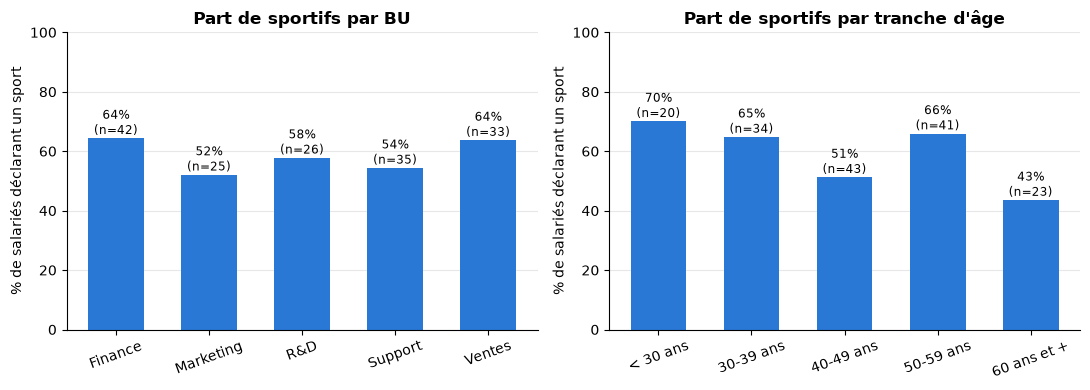

In [9]:
# Taux de pratique par BU et par tranche d'âge
taux_bu = df.groupby("bu")["pratique_sport"].agg(["sum", "count", "mean"])
taux_age = df.groupby("tranche_age", observed=True)["pratique_sport"].agg(["sum", "count", "mean"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, taux, titre in [(axes[0], taux_bu, "par BU"), (axes[1], taux_age, "par tranche d'âge")]:
    ax.bar(taux.index.astype(str), taux["mean"] * 100, color=BLEU, width=0.6)
    for x, (m, n) in enumerate(zip(taux["mean"], taux["count"])):
        ax.text(x, m * 100 + 1.5, f"{m:.0%}\n(n={n})", ha="center", fontsize=8.5)
    ax.set_title(f"Part de sportifs {titre}")
    ax.set_ylabel("% de salariés déclarant un sport")
    ax.set_ylim(0, 100)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 3. Profil des salariés

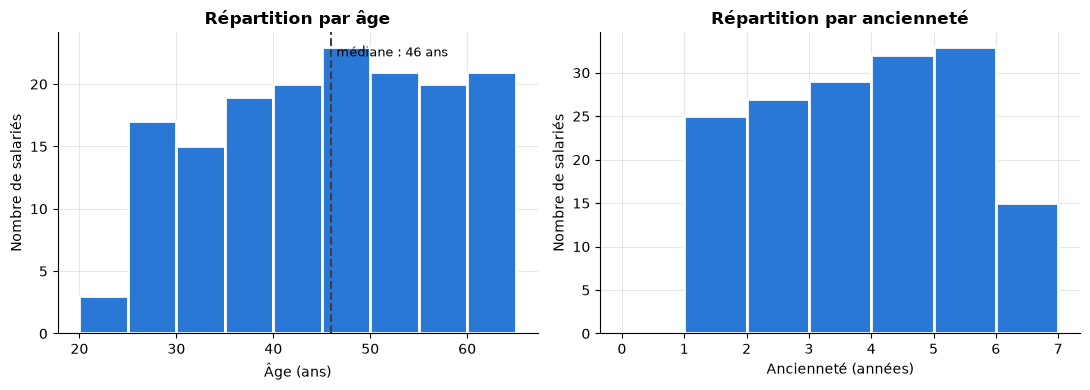

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["age"], bins=range(20, 70, 5), color=BLEU, edgecolor="white", linewidth=2)
axes[0].axvline(df["age"].median(), color="#3d3d3a", linestyle="--", linewidth=1.5)
axes[0].text(df["age"].median() + 0.5, axes[0].get_ylim()[1] * 0.92, f"médiane : {df['age'].median():.0f} ans", fontsize=9)
axes[0].set_title("Répartition par âge")
axes[0].set_xlabel("Âge (ans)")
axes[0].set_ylabel("Nombre de salariés")

axes[1].hist(df["anciennete"], bins=range(0, int(df["anciennete"].max()) + 2), color=BLEU, edgecolor="white", linewidth=2)
axes[1].set_title("Répartition par ancienneté")
axes[1].set_xlabel("Ancienneté (années)")
axes[1].set_ylabel("Nombre de salariés")

plt.tight_layout()
plt.show()

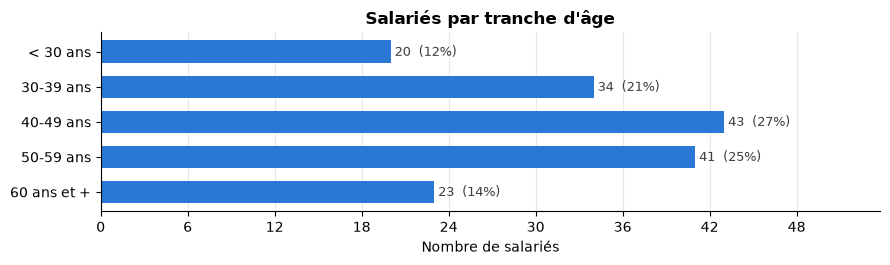

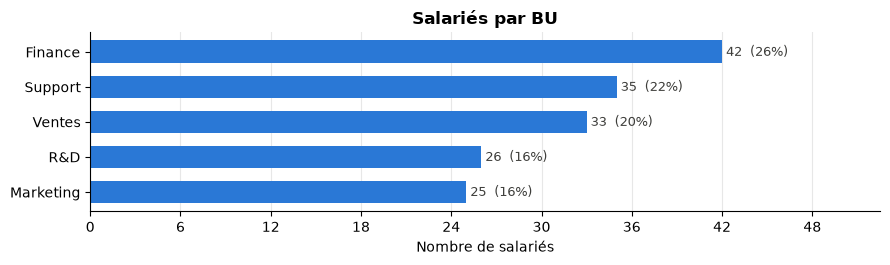

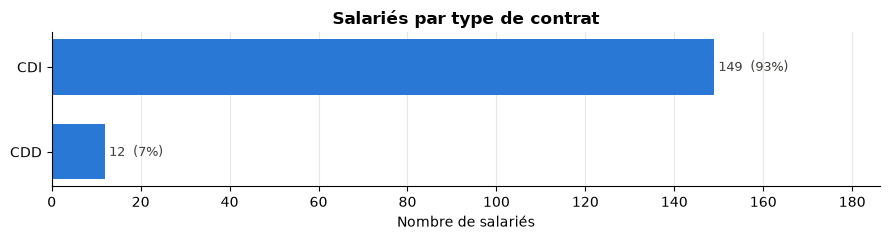

In [11]:
barres_horizontales(df["tranche_age"].value_counts().sort_index(), "Salariés par tranche d'âge", trier=False)
barres_horizontales(df["bu"].value_counts(), "Salariés par BU")
barres_horizontales(df["type_contrat"].value_counts(), "Salariés par type de contrat")

## 4. Moyens de transport domicile-bureau

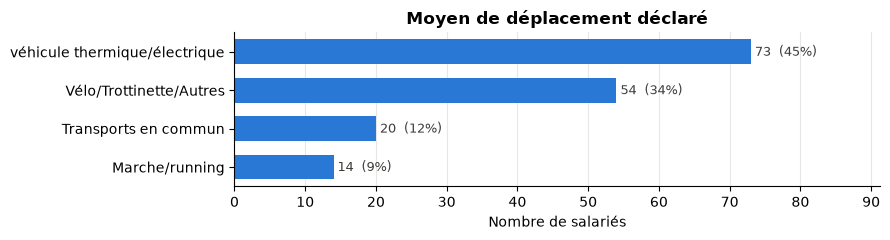

68 salariés (42%) déclarent venir au bureau de façon sportive -> potentiellement éligibles à la prime de 5 %.


In [12]:
barres_horizontales(df["moyen_deplacement"].value_counts(), "Moyen de déplacement déclaré")

n_trajet = df["trajet_sportif"].sum()
print(f"{n_trajet} salariés ({n_trajet / n_total:.0%}) déclarent venir au bureau de façon sportive "
      "-> potentiellement éligibles à la prime de 5 %.")

In [13]:
# Croisement mode de transport x pratique sportive
pd.crosstab(df["moyen_deplacement"], df["pratique_sport"].map({True: "Sport déclaré", False: "Aucun sport"}),
            margins=True, margins_name="Total")

pratique_sport,Aucun sport,Sport déclaré,Total
moyen_deplacement,,,
Marche/running,6,8,14
Transports en commun,8,12,20
Vélo/Trottinette/Autres,25,29,54
véhicule thermique/électrique,27,46,73
Total,66,95,161


## 5. Localisation des domiciles

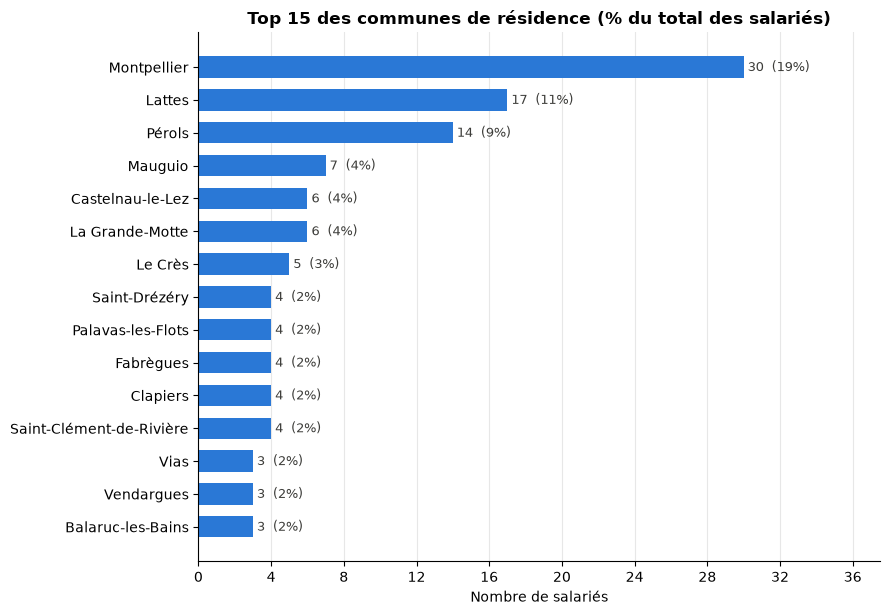

Répartition par département : {'Hérault (34)': 156, 'Gard (30)': 4, 'Autre': 1}
52 communes différentes ; 28 communes n'ont qu'un seul salarié.


In [14]:
barres_horizontales(df["commune"].value_counts().head(15), "Top 15 des communes de résidence (% du total des salariés)",
                    total=len(df))

par_dep = df["departement"].map({"34": "Hérault (34)", "30": "Gard (30)"}).fillna("Autre").value_counts()
print("Répartition par département :", par_dep.to_dict())
print(f"{df['commune'].nunique()} communes différentes ; "
      f"{(df['commune'].value_counts() == 1).sum()} communes n'ont qu'un seul salarié.")

## 6. Détection des déclarations suspectes

La note de cadrage fixe les règles suivantes pour la prime :

| Mode déclaré | Distance maximale |
|---|---|
| Marche/running | 15 km |
| Vélo/Trottinette/Autres | 25 km |

**Méthode d'exploration (estimation)** : chaque commune est géolocalisée avec l'API publique
`geo.api.gouv.fr` (gratuite, sans clé). On calcule la distance **à vol d'oiseau** entre le centre de la
commune et l'entreprise, multipliée par un **coefficient de détour de 1,3** pour approcher la distance
par la route.

> Cette estimation sert à repérer les cas évidents. Le calcul **définitif** (distance réelle à pied ou à vélo,
> à l'adresse exacte) sera fait dans le pipeline avec l'**API Google Routes**, comme demandé par la note.

Les coordonnées sont mises en cache dans `data/interim/` (à ajouter au `.gitignore`) pour ne pas
réinterroger l'API à chaque exécution.

In [15]:
CACHE_GEO = RACINE / "data" / "interim" / "geocodage_communes.csv"
ADRESSE_ENTREPRISE = "1362 Av. des Platanes, 34970 Lattes"
COEF_DETOUR = 1.3
SEUILS_KM = {"Marche/running": 15, "Vélo/Trottinette/Autres": 25}


def _normaliser(texte):
    texte = unicodedata.normalize("NFKD", texte).encode("ascii", "ignore").decode()
    return texte.lower().replace("-", " ").replace("'", " ").strip()


def _appel_json(url):
    with urllib.request.urlopen(url, timeout=10) as reponse:
        return json.load(reponse)


def geocoder_commune(commune, departement):
    """Centre géographique d'une commune via geo.api.gouv.fr."""
    parametres = {"nom": commune, "fields": "nom,code,centre,codesPostaux", "limit": 5}
    if isinstance(departement, str):   # filtre par département quand on le connaît
        parametres["codeDepartement"] = departement
    url = "https://geo.api.gouv.fr/communes?" + urllib.parse.urlencode(parametres)
    resultats = _appel_json(url)
    if not resultats:
        return None
    # On privilégie la correspondance exacte du nom (l'API renvoie aussi des noms proches)
    exact = [r for r in resultats if _normaliser(r["nom"]) == _normaliser(commune)]
    r = (exact or resultats)[0]
    lon, lat = r["centre"]["coordinates"]
    return {"commune": commune, "departement": departement, "nom_officiel": r["nom"],
            "code_insee": r["code"], "lat": lat, "lon": lon,
            "codes_postaux": "|".join(r.get("codesPostaux", []))}


def geocoder_adresse(adresse):
    """Coordonnées d'une adresse précise via la Base Adresse Nationale."""
    url = "https://api-adresse.data.gouv.fr/search/?" + urllib.parse.urlencode({"q": adresse, "limit": 1})
    lon, lat = _appel_json(url)["features"][0]["geometry"]["coordinates"]
    return lat, lon


def distance_vol_oiseau_km(lat1, lon1, lat2, lon2):
    """Formule de haversine."""
    rayon = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp, dl = p2 - p1, math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * rayon * math.asin(math.sqrt(a))

In [16]:
# Géocodage des communes (avec cache)
communes = df[["commune", "departement"]].dropna(subset=["commune"]).drop_duplicates()

if CACHE_GEO.exists():
    geo = pd.read_csv(CACHE_GEO, dtype={"departement": str, "code_insee": str, "codes_postaux": str})
    print(f"Cache chargé : {len(geo)} communes")
else:
    lignes, echecs = [], []
    for c in communes.itertuples(index=False):
        try:
            resultat = geocoder_commune(c.commune, c.departement)
            (lignes if resultat else echecs).append(resultat or c.commune)
        except Exception as erreur:
            echecs.append(f"{c.commune} ({erreur})")
    geo = pd.DataFrame(lignes)
    CACHE_GEO.parent.mkdir(parents=True, exist_ok=True)
    geo.to_csv(CACHE_GEO, index=False)
    print(f"{len(geo)} communes géocodées, {len(echecs)} échecs : {echecs}")

# Coordonnées de l'entreprise
try:
    LAT_ENT, LON_ENT = geocoder_adresse(ADRESSE_ENTREPRISE)
    print(f"Entreprise géolocalisée : {LAT_ENT:.4f}, {LON_ENT:.4f}")
except Exception as erreur:
    # Repli : centre de la commune de Lattes (moins précis, de l'ordre de 2 km)
    lattes = geo.loc[geo["commune"] == "Lattes"].iloc[0]
    LAT_ENT, LON_ENT = lattes["lat"], lattes["lon"]
    print(f"⚠️ Adresse de l'entreprise non géocodée ({erreur}) : centre de Lattes utilisé")

53 communes géocodées, 0 échecs : []
Entreprise géolocalisée : 43.5858, 3.9232


In [17]:
# Distance estimée domicile -> bureau
df = df.drop(columns=["lat", "lon", "codes_postaux"], errors="ignore").merge(
    geo[["commune", "departement", "lat", "lon", "codes_postaux"]],
    on=["commune", "departement"], how="left",
)
df["distance_vol_oiseau_km"] = [
    distance_vol_oiseau_km(lat, lon, LAT_ENT, LON_ENT) if pd.notna(lat) else np.nan
    for lat, lon in zip(df["lat"], df["lon"])
]
df["distance_estimee_km"] = df["distance_vol_oiseau_km"] * COEF_DETOUR
df["seuil_km"] = df["moyen_deplacement"].map(SEUILS_KM)
df["declaration_suspecte"] = df["distance_estimee_km"] > df["seuil_km"]

print("Communes non géolocalisées :", df["lat"].isna().sum(), "salarié(s) concerné(s)")
df.groupby("moyen_deplacement")["distance_estimee_km"].describe().round(1)

Communes non géolocalisées : 0 salarié(s) concerné(s)


,count,mean,std,min,25%,50%,75%,max
moyen_deplacement,,,,,,,,
Marche/running,14.0,4.0,0.5,3.7,3.7,3.7,4.6,4.6
Transports en commun,20.0,10.3,7.5,4.6,6.2,6.2,10.2,31.4
Vélo/Trottinette/Autres,54.0,8.1,3.9,3.7,6.2,6.2,9.4,18.7
véhicule thermique/électrique,73.0,30.7,21.1,3.7,15.7,23.4,44.5,80.0


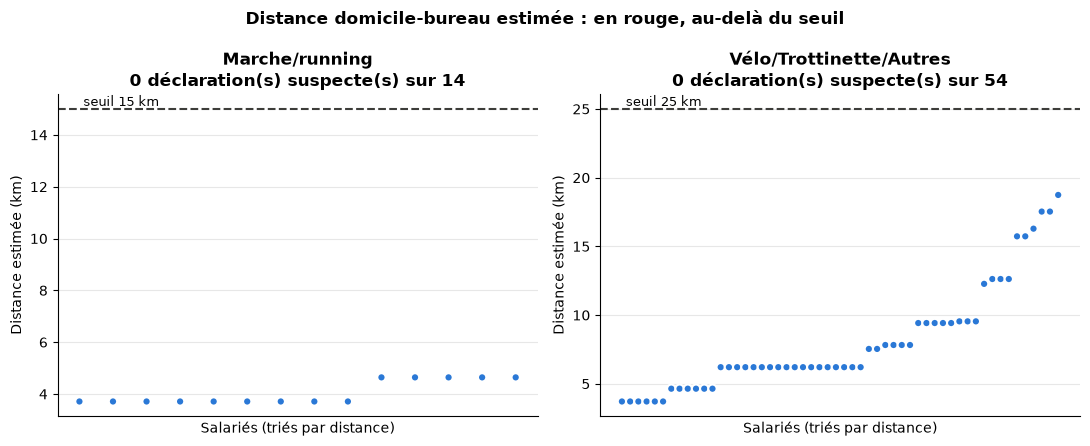

In [18]:
# Distance estimée des salariés au trajet sportif, comparée au seuil
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
for ax, (mode, seuil) in zip(axes, SEUILS_KM.items()):
    sous = df[df["moyen_deplacement"] == mode].sort_values("distance_estimee_km").reset_index(drop=True)
    couleurs = np.where(sous["declaration_suspecte"], ROUGE, BLEU)
    ax.scatter(sous.index, sous["distance_estimee_km"], c=couleurs, s=36, edgecolors="white", linewidths=1.5, zorder=3)
    ax.axhline(seuil, color="#3d3d3a", linestyle="--", linewidth=1.5)
    ax.text(0, seuil, f" seuil {seuil} km", va="bottom", fontsize=9)
    n_susp = sous["declaration_suspecte"].sum()
    ax.set_title(f"{mode}\n{n_susp} déclaration(s) suspecte(s) sur {len(sous)}")
    ax.set_xlabel("Salariés (triés par distance)")
    ax.set_ylabel("Distance estimée (km)")
    ax.set_xticks([])
plt.suptitle("Distance domicile-bureau estimée : en rouge, au-delà du seuil", fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
# Liste des déclarations à faire vérifier par les RH (identifiants seulement)
suspects = (
    df.loc[df["declaration_suspecte"],
           ["id_salarie", "moyen_deplacement", "commune", "distance_estimee_km", "seuil_km"]]
    .assign(depassement_km=lambda d: d["distance_estimee_km"] - d["seuil_km"])
    .sort_values("depassement_km", ascending=False)
    .round(1)
)
print(f"{len(suspects)} déclaration(s) suspecte(s) sur {df['trajet_sportif'].sum()} trajets sportifs déclarés")
suspects

0 déclaration(s) suspecte(s) sur 68 trajets sportifs déclarés


,id_salarie,moyen_deplacement,commune,distance_estimee_km,seuil_km,depassement_km


In [20]:
# Bonus qualité : le code postal correspond-il à la commune ?
df["cp_coherent"] = [
    cp in str(cps).split("|") if pd.notna(cps) else np.nan
    for cp, cps in zip(df["code_postal"], df["codes_postaux"])
]
incoherents = df.loc[df["cp_coherent"] == False, ["id_salarie", "code_postal", "commune", "codes_postaux"]]  # noqa: E712
print(f"{len(incoherents)} adresse(s) dont le code postal ne correspond pas à la commune")
incoherents.head(10)

4 adresse(s) dont le code postal ne correspond pas à la commune


,id_salarie,code_postal,commune,codes_postaux
0,59019,34000,Frontignan,34110
1,19841,34970,Saint-Clément-de-Rivière,34980
21,15493,34880,La Grande-Motte,34280
22,84233,NaN,Montpellier,34000|34070|34080|34090


## 7. Premier ordre de grandeur du coût

Hypothèses (à affiner dans le pipeline) :
- **Prime** : 5 % du salaire brut annuel pour chaque salarié déclarant un trajet sportif.
- **Journées bien-être** : borne haute = tous les salariés déclarant un sport obtiennent 5 jours.
  L'éligibilité réelle (au moins 15 activités par an) sera calculée à partir des données d'activité.
  Une journée est valorisée à salaire brut annuel / 218 jours travaillés.

In [21]:
TAUX_PRIME = 0.05
JOURS_BIEN_ETRE = 5
JOURS_TRAVAILLES = 218

prime_toutes = df.loc[df["trajet_sportif"], "salaire_brut"].sum() * TAUX_PRIME
prime_sans_suspects = df.loc[df["trajet_sportif"] & ~df["declaration_suspecte"], "salaire_brut"].sum() * TAUX_PRIME
cout_journees = (df.loc[df["pratique_sport"], "salaire_brut"] / JOURS_TRAVAILLES * JOURS_BIEN_ETRE).sum()

synthese_cout = pd.DataFrame({
    "Bénéficiaires": [df["trajet_sportif"].sum(),
                      (df["trajet_sportif"] & ~df["declaration_suspecte"]).sum(),
                      df["pratique_sport"].sum()],
    "Coût annuel (€)": [prime_toutes, prime_sans_suspects, cout_journees],
}, index=["Prime : toutes les déclarations",
          "Prime : hors déclarations suspectes",
          "Journées bien-être (borne haute)"])
synthese_cout["Coût annuel (€)"] = synthese_cout["Coût annuel (€)"].round(0).astype(int)
print(f"Masse salariale : {df['salaire_brut'].sum():,.0f} €".replace(",", " "))
synthese_cout

Masse salariale : 8 118 630 €


,Bénéficiaires,Coût annuel (€)
Prime : toutes les déclarations,68,172482
Prime : hors déclarations suspectes,68,172482
Journées bien-être (borne haute),95,109668


## 8. Synthèse

In [22]:
def euros(montant):
    return f"{montant:,.0f} €".replace(",", " ")


print(f"""
Population            : {n_total} salariés, âge médian {df['age'].median():.0f} ans, {df['bu'].nunique()} BU
Pratique sportive     : {n_sport} salariés déclarent un sport ({n_sport / n_total:.0%}), {df['sport'].nunique()} sports différents
Sport le plus pratiqué: {df['sport'].value_counts().index[0]} ({df['sport'].value_counts().iloc[0]} salariés)
Trajets sportifs      : {df['trajet_sportif'].sum()} salariés ({df['trajet_sportif'].mean():.0%})
Déclarations suspectes: {df['declaration_suspecte'].sum()} (distance estimée au-delà du seuil)
Qualité               : aucune valeur manquante côté RH ; 1 libellé à corriger ('Runing') ;
                        {sans_cp.sum()} adresse(s) sans code postal, {sans_virgule.sum()} sans virgule ;
                        {len(incoherents)} code(s) postal(aux) incohérent(s) avec la commune
Coût prime            : {euros(prime_sans_suspects)} / an (hors suspects) à {euros(prime_toutes)} / an
Coût journées         : jusqu'à {euros(cout_journees)} / an (borne haute)
""")


Population            : 161 salariés, âge médian 46 ans, 5 BU
Pratique sportive     : 95 salariés déclarent un sport (59%), 15 sports différents
Sport le plus pratiqué: Course à pied (18 salariés)
Trajets sportifs      : 68 salariés (42%)
Déclarations suspectes: 0 (distance estimée au-delà du seuil)
Qualité               : aucune valeur manquante côté RH ; 1 libellé à corriger ('Runing') ;
                        1 adresse(s) sans code postal, 1 sans virgule ;
                        4 code(s) postal(aux) incohérent(s) avec la commune
Coût prime            : 172 482 € / an (hors suspects) à 172 482 € / an
Coût journées         : jusqu'à 109 668 € / an (borne haute)



**Suites pour le pipeline :**
- corriger le libellé `Runing` lors de l'ingestion (dbt, couche staging) ;
- calculer les distances réelles avec l'**API Google Routes** (mode `WALK` / `BICYCLE`) et confirmer ou non
  les déclarations suspectes repérées ici ;
- calculer l'éligibilité réelle aux journées bien-être à partir des activités (au moins 15 par an) ;
- garder les paramètres (taux, seuils, nombre de jours) dans une table, pour pouvoir tout recalculer.